In [1]:
import sys
import os

src_path = os.path.abspath(os.path.join('..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)
    
from Load_EEG_Data import *
from Build_Vineyard import *
from Plot_Vineyard import *

In [2]:
subject_ids = ['sub-02', 'sub-03', 'sub-04', 'sub-05', 'sub-06', 'sub-07', 'sub-08', 'sub-09', 'sub-10', 'sub-12']

In [3]:
subject = 'sub-02'
run_id = 'run-1' # from run-1 to run-4
freq = 'alpha' # 'alpha' or 'beta'
task_name = 'task-MIvsRest'
window_size = 30 
step_size = 2
sfreq = 125.0

In [4]:
distance_matrices = load_eeg_data(subject_id = subject,
                                  run_id = run_id,
                                  freq = freq,
                                  win_size = window_size,
                                  step_size = step_size
                                  )

--- sub-02 (alpha 대역) 처리 시작 ---
--- sub-02: 거리 행렬 생성 완료 (크기: (209, (15, 15))) ---


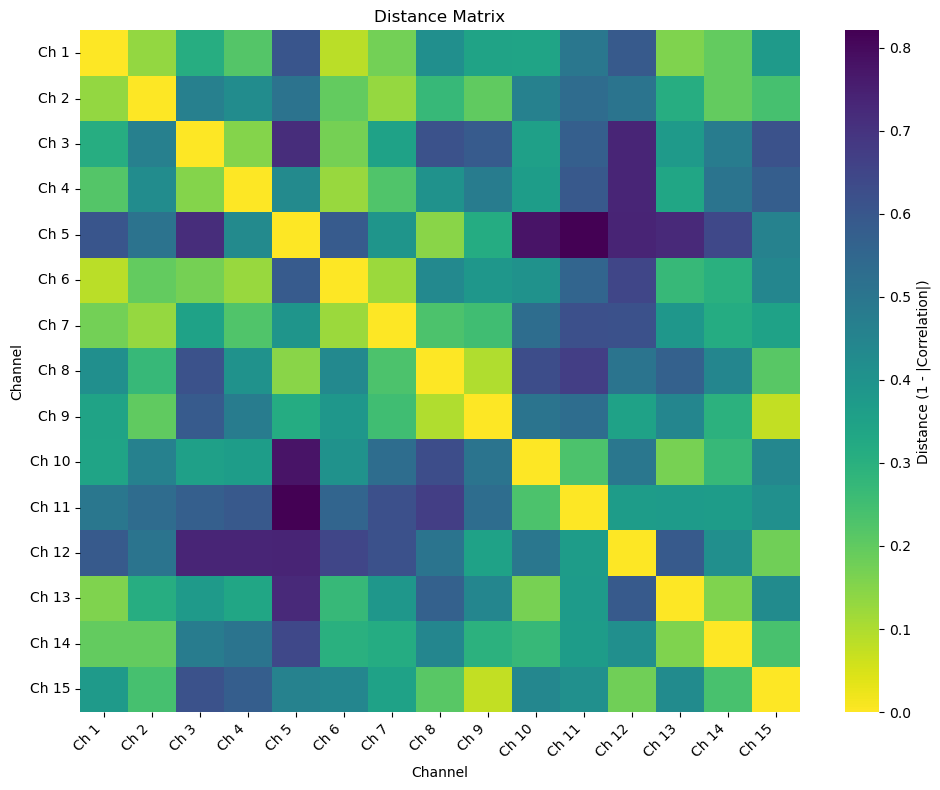

In [5]:
plot_distance_matrix(distance_matrices[0])

In [6]:
sanity_check_distance_matrix(distance_matrices[0])


--- Distance Matrix Sanity Check ---
  Shape                : (15, 15)
  Number of entries    : 225
  Is square matrix     : True
  Expected entries     : 15 * 15 = 225
  Min value            : 0.0000
  Max value            : 0.8208
  Any NaNs             : False
  Any Infs             : False
  Diagonal elements ~0 : True
  Is symmetric         : True
  All non-negative     : True


In [7]:
diagrams_H0, diagrams_H1 = compute_persistence_diagram(distance_matrices)

  Processing matrix for window 20/209
  Processing matrix for window 40/209
  Processing matrix for window 60/209
  Processing matrix for window 80/209
  Processing matrix for window 100/209
  Processing matrix for window 120/209
  Processing matrix for window 140/209
  Processing matrix for window 160/209
  Processing matrix for window 180/209
  Processing matrix for window 200/209
  Processing matrix for window 209/209
  H0 Diagrams: 209. (First H0 shape: (15, 2))
  H1 Diagrams: 209. (First H1 shape: (4, 2))


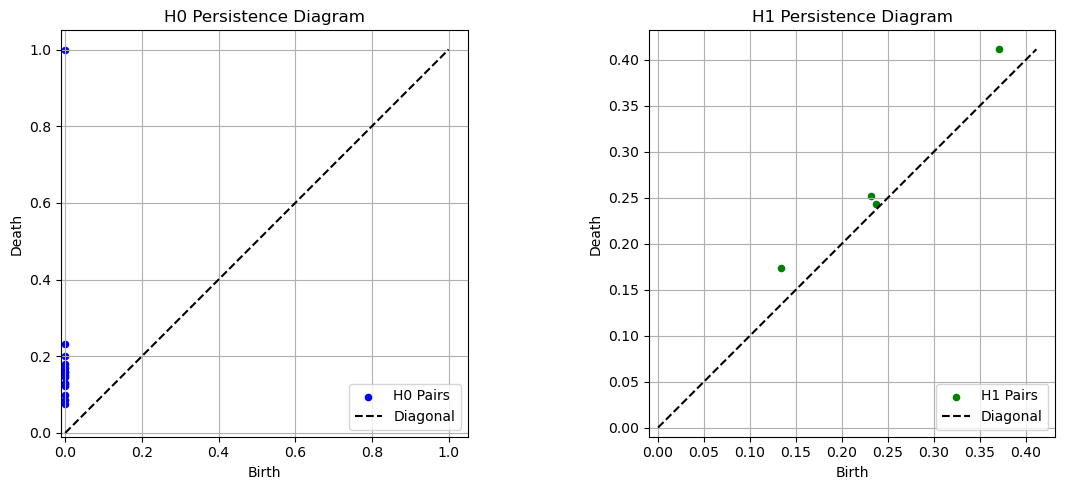

In [8]:
plot_persistence_diagrams(diagrams_H0[0], diagrams_H1[0])

In [9]:
vines_H0 = build_vines(diagrams_H0, match_threshold=0.3)
vines_H1 = build_vines(diagrams_H1, match_threshold=0.3)

In [10]:
scores_H0 = vines_to_time_value(vines_H0)
scores_H1 = vines_to_time_value(vines_H1)

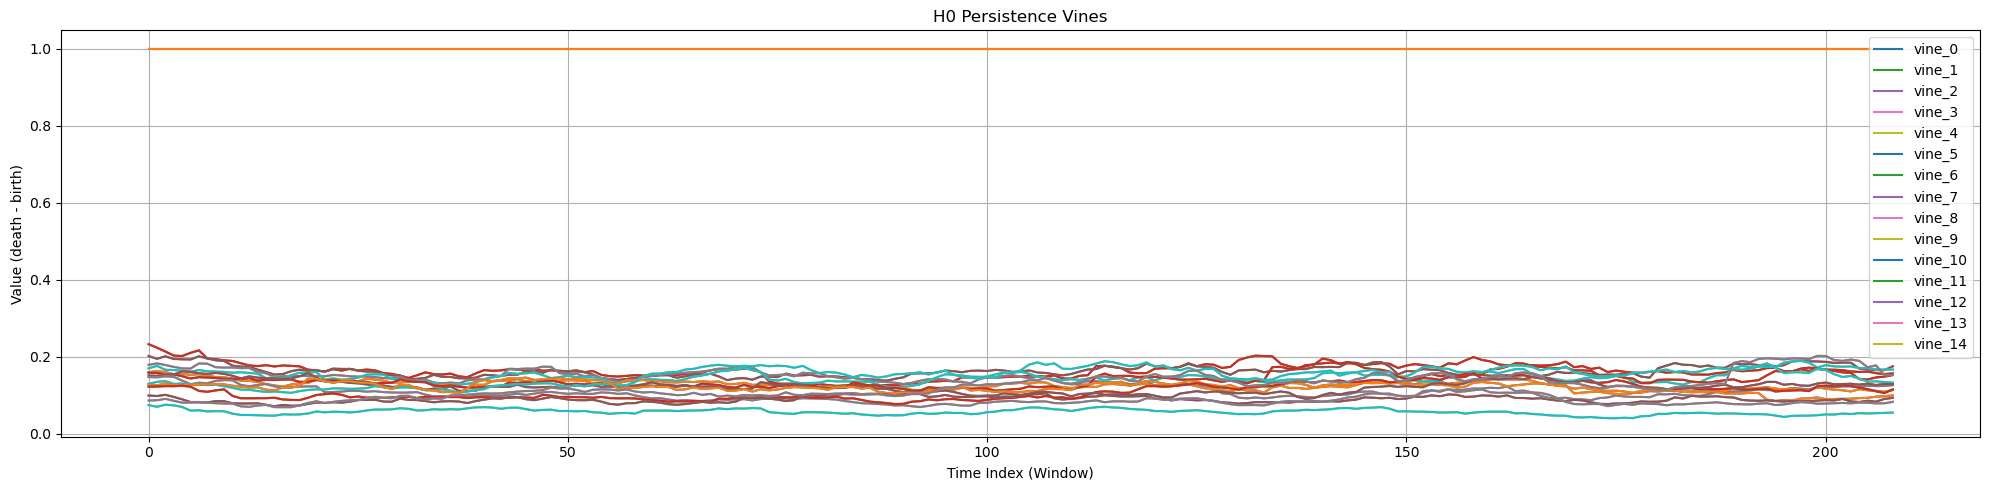

In [11]:
plot_selected_vines(scores_H0, title="H0 Persistence Vines", num_vines_to_plot=15)

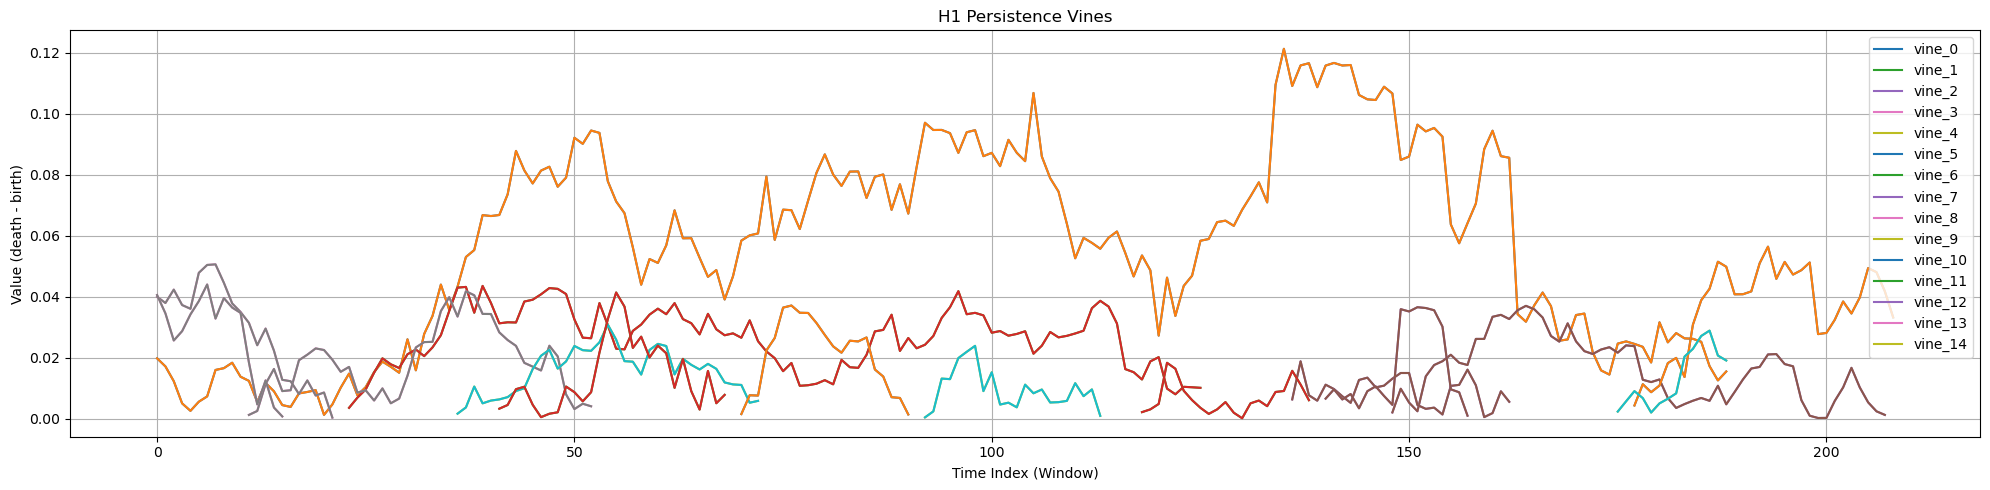

In [12]:
plot_selected_vines(scores_H1, title="H1 Persistence Vines")

In [13]:
DATA_PATH = "../Dataset/EEG/" # 사용자 설정 경로
output_derivatives_dir = os.path.join(DATA_PATH, 'derivatives')
block_details_file_path = os.path.join(output_derivatives_dir, 'all_subjects_event_details.json')
# --- 2. 저장된 JSON 파일에서 all_subjects_event_details 딕셔너리 불러오기 ---
all_subjects_block_details = None # 초기화
if os.path.exists(block_details_file_path):
    try:
        with open(block_details_file_path, 'r') as f:
            all_subjects_block_details = json.load(f)
        print(f"파일에서 이벤트 블록 상세 정보를 성공적으로 불러왔습니다: {block_details_file_path}")
    except Exception as e:
        print(f"파일 불러오기 중 오류 발생: {e}")
else:
    print(f"저장된 이벤트 블록 상세 정보 파일을 찾을 수 없습니다: {block_details_file_path}")

파일에서 이벤트 블록 상세 정보를 성공적으로 불러왔습니다: ../Dataset/EEG/derivatives\all_subjects_event_details.json


In [14]:
event_color_map = {
    'Rest': 'lightcoral',  # 휴식
    'Motor Imagery': 'cornflowerblue', # 오른손 운동 상상
    'UNKNOWN_EVENT': 'lightgrey',      # 알 수 없는 이벤트 또는 이벤트 없는 구간
    'NO_EVENT_DATA': 'white'           # 해당 윈도우에 매칭되는 이벤트 블록이 없을 경우 (경계 등)
}

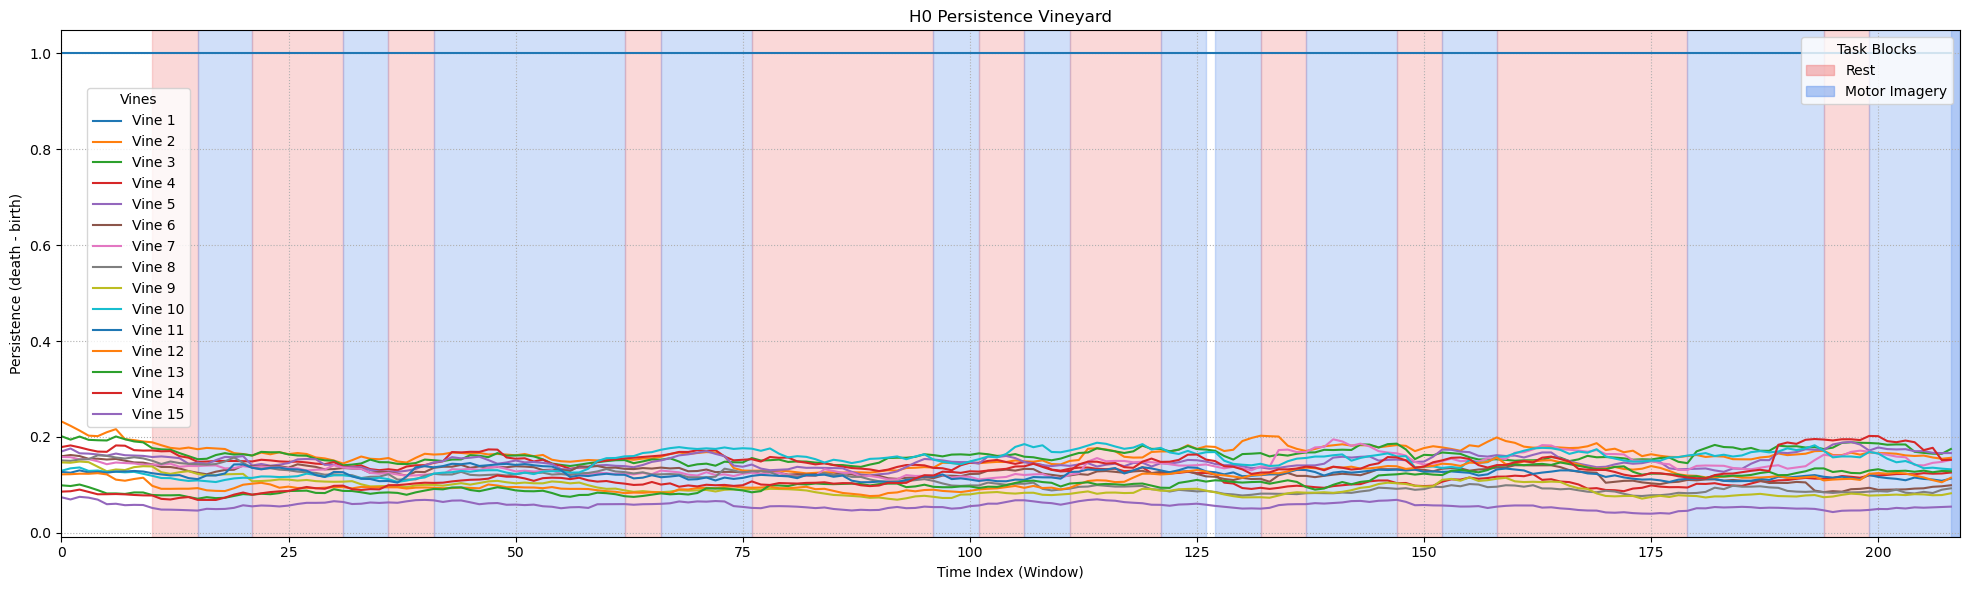

In [15]:
plot_vines_with_event_blocks(
        subject_event_blocks_data=all_subjects_block_details[subject],
        vines_data_time_value=scores_H0, # scores_H0 또는 scores_H1 전달
        sfreq=sfreq,
        window_len_sec=window_size,
        step_len_sec=step_size,
        event_colors=event_color_map,
        plot_title=f"H0 Persistence Vineyard",
        num_vines_to_plot=15,
        y_label="Persistence (death - birth)" # Y축 레이블 명확화
    )

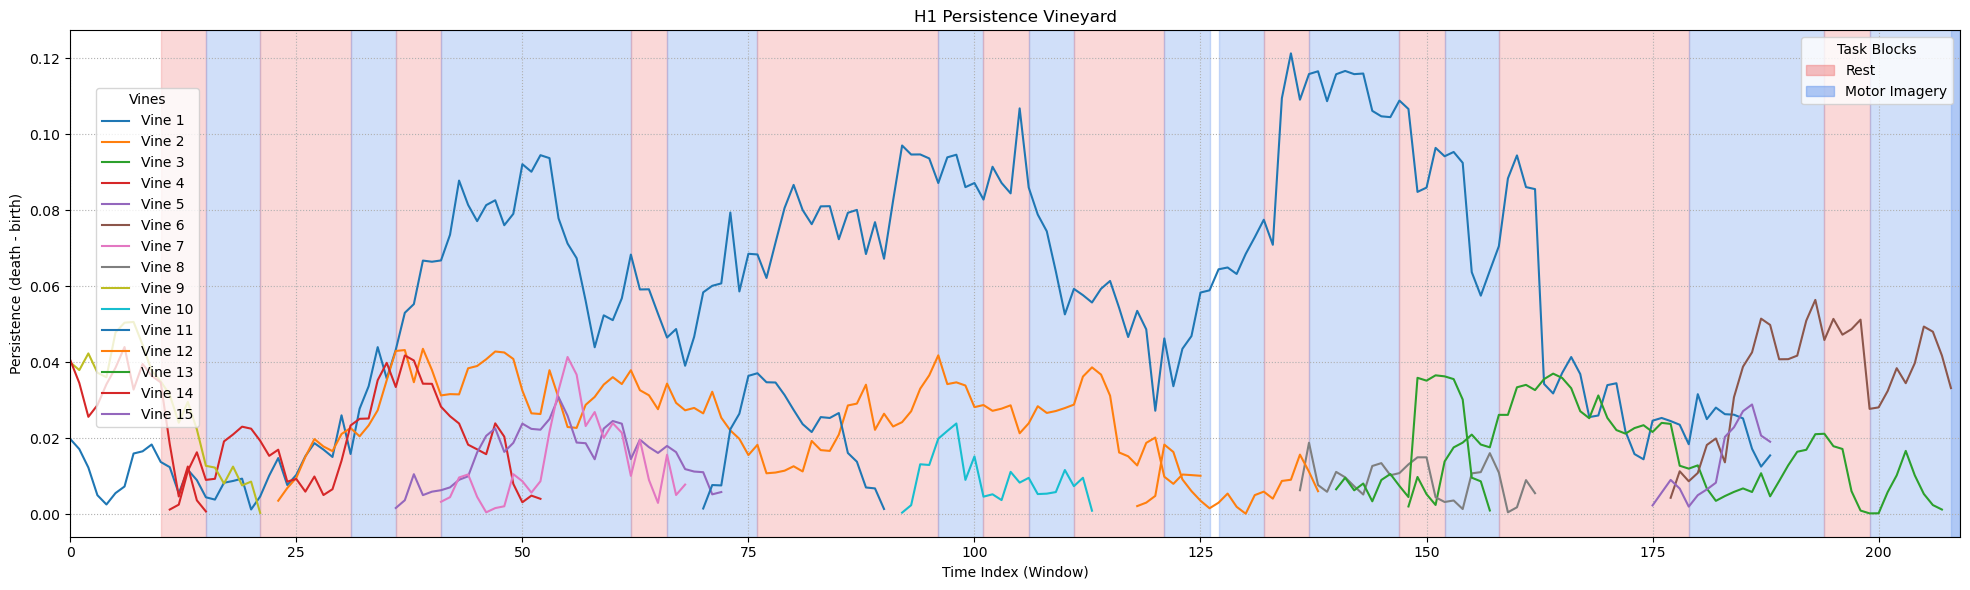

In [16]:
plot_vines_with_event_blocks(
        subject_event_blocks_data=all_subjects_block_details[subject],
        vines_data_time_value=scores_H1, # scores_H0 또는 scores_H1 전달
        sfreq=sfreq,
        window_len_sec=window_size,
        step_len_sec=step_size,
        event_colors=event_color_map,
        plot_title=f"H1 Persistence Vineyard",
        num_vines_to_plot=15,
        y_label="Persistence (death - birth)" # Y축 레이블 명확화
    )

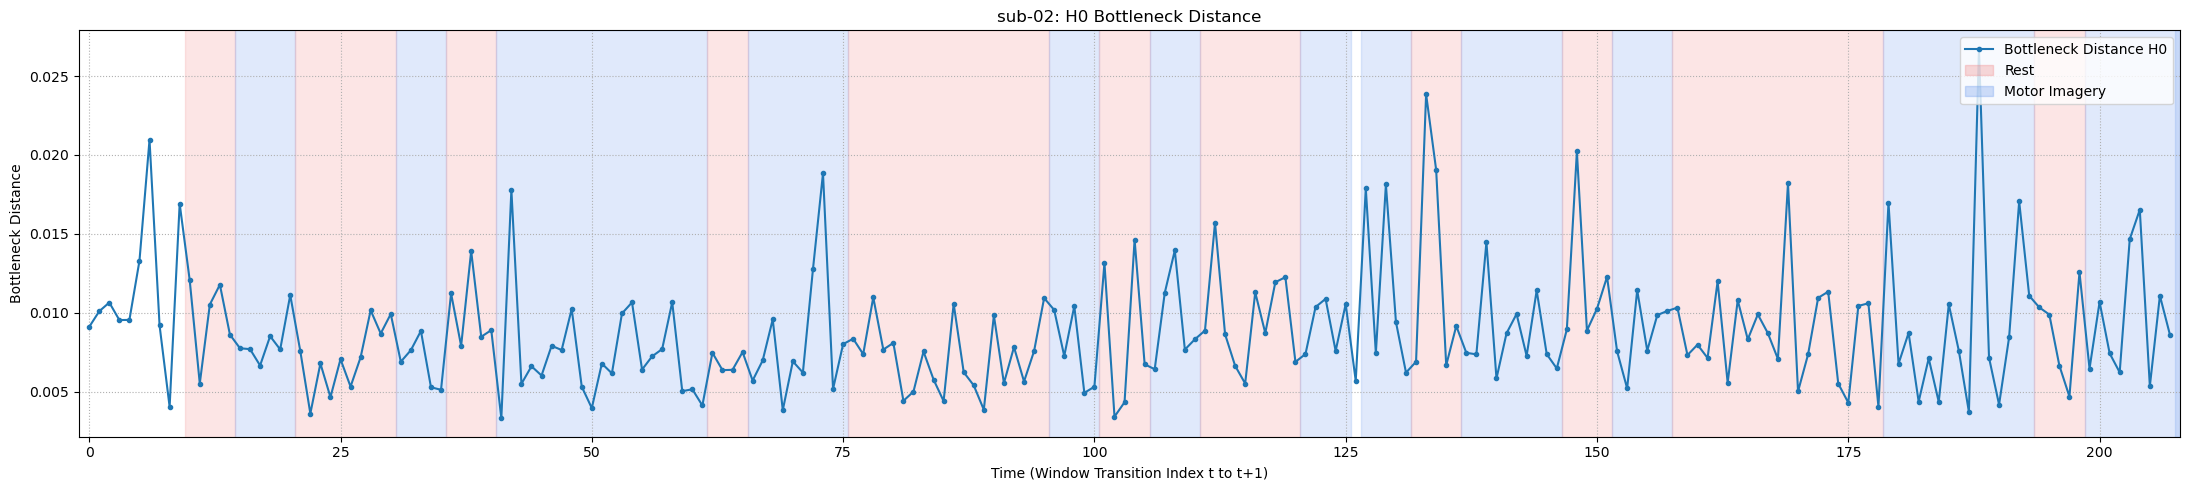

In [17]:
current_num_windows = len(diagrams_H0) if diagrams_H0 else 0
bottleneck_distances_H0 = compute_bottleneck_distance_series(diagrams_H0)
plot_bottleneck_distance_with_event_blocks(
                bottleneck_distances_H0, "H0", subject,
                all_subjects_block_details[subject],
                sfreq, window_size, step_size,
                current_num_windows, 
                event_color_map, task_name.capitalize()
            )


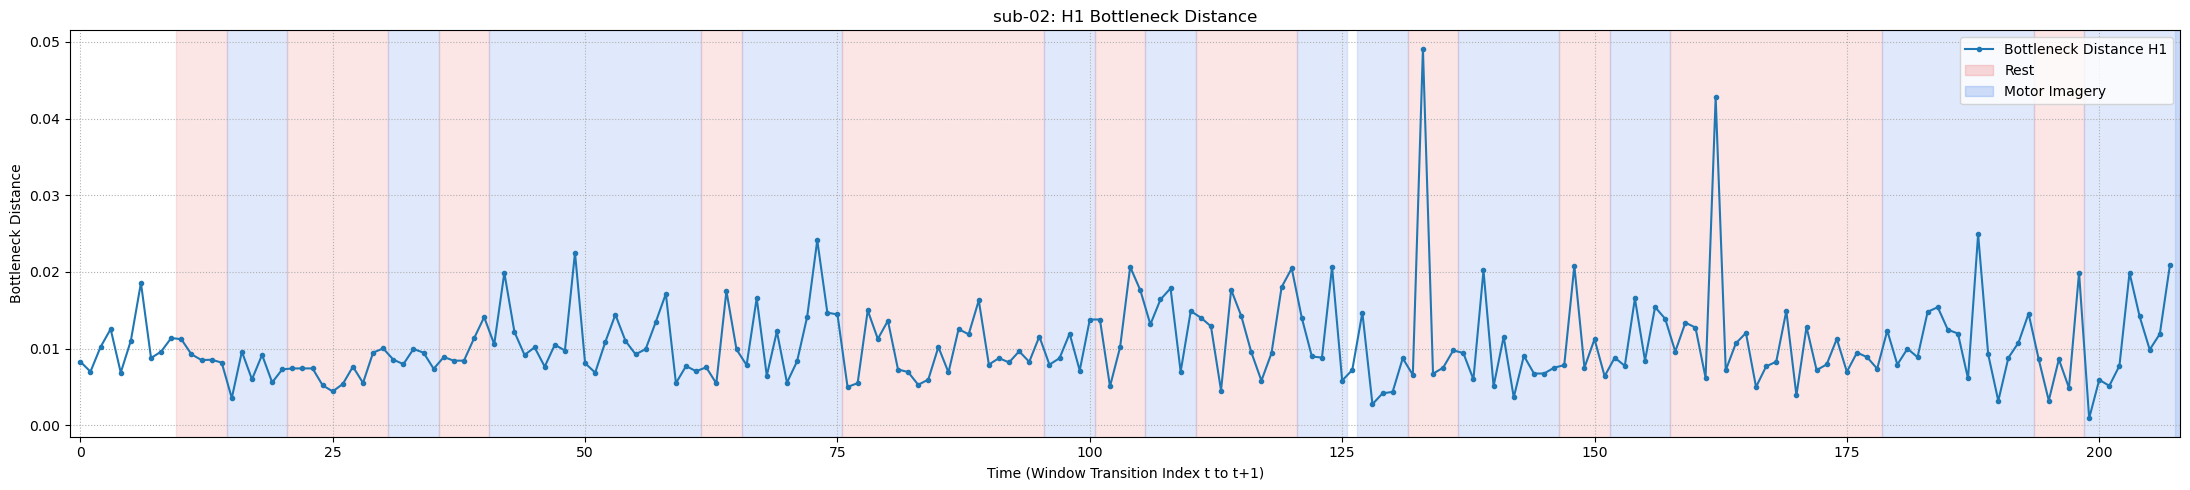

In [18]:
current_num_windows = len(diagrams_H1) if diagrams_H1 else 0
bottleneck_distances_H1 = compute_bottleneck_distance_series(diagrams_H1)
plot_bottleneck_distance_with_event_blocks(
                bottleneck_distances_H1, "H1", subject,
                all_subjects_block_details[subject],
                sfreq, window_size, step_size,
                current_num_windows, 
                event_color_map, task_name.capitalize()
            )